# Exam 16th of January 2026, 8.00-13.00 for the course 1MS041 (Introduction to Data Science / Introduktion till dataanalys)

## Instructions:
1. Complete the problems by following instructions.
2. When done, submit this file with your solutions saved, following the instruction sheet.

This exam has 3 problems for a total of 40 points, to pass you need
20 points. The bonus will be added to the score of the exam and rounded afterwards.

## Some general hints and information:
* Try to answer all questions even if you are uncertain.
* Comment your code, so that if you get the wrong answer I can understand how you thought
this can give you some points even though the code does not run.
* Follow the instruction sheet rigorously.
* This exam is partially autograded, but your code and your free text answers are manually graded anonymously.
* If there are any questions, please ask the exam guards, they will escalate it to me if necessary.

## Tips for free text answers
* Be VERY clear with your reasoning, there should be zero ambiguity in what you are referring to.
* If you want to include math, you can write LaTeX in the Markdown cells, for instance `$f(x)=x^2$` will be rendered as $f(x)=x^2$ and `$$f(x) = x^2$$` will become an equation line, as follows
$$f(x) = x^2$$
Another example is `$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$` which renders as
$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$

## Finally some rules:
* You may not communicate with others during the exam, for example:
    * You cannot ask for help in Stack-Overflow or other such help forums during the Exam.
    * You may not communicate with AI's, for instance ChatGPT.
    * Your on-line and off-line activity is being monitored according to the examination rules.

## Good luck!

In [1]:
# Insert your anonymous exam ID as a string in the variable below
examID="0035-HKR"


---
## Exam vB, PROBLEM 1
Maximum Points = 14


This problem is about **SVD** and a simple **anomaly detection** idea using low-rank reconstruction.



Unless stated otherwise, when you are asked to produce a matrix or vector, it must be a **NumPy array**.

1. **[4p] SVD.** Load `data/SVD.csv` as instructed in the code cell. Let $X$ be the data matrix of shape `n_samples × n_dimensions`. Compute an SVD
   $$X = U D V^T$$
   where $U$ has shape `n_samples × n_dimensions`, $D$ is the diagonal matrix of shape `(n_dimensions,n_dimensions)` that has the singular values on the diagonal (see documentation for `np.diag`), and $V$ has shape `n_dimensions × n_dimensions`.
   **Important:** `np.linalg.svd` returns `U, d, Vt` where `Vt` is $V^T$.
   Also extract the **first** right and left singular vectors and store them as 1D arrays in the variables provided.

2. **[3p] Explained variance.** For $N =$ `n_dimensions`, define the explained variance using the first $k$ singular values as
   $$
   \mathrm{EV}(k) = \frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^N \sigma_i^2}.
   $$
   Compute $\mathrm{EV}(k)$ for $k=1,2,\dots,N$ and store it in `problem1_explained_variance` (length `N`). Then set `problem1_num_components` to the **smallest** $k$ such that $\mathrm{EV}(k) \ge 0.99$.

3. **[3p] Plot + interpretation.** Plot explained variance (x-axis: number of components $k$, y-axis: $\mathrm{EV}(k)$). In the markdown cell below, reason about the shape of the curve for this dataset.

4. **[4p] Low-rank reconstruction + outliers.**
   - Using `problem1_num_components`, construct the best rank-$k$ approximation of $X$ and store it in `problem1_approximation`.
   - Compute the row-wise Euclidean reconstruction error $\|X_i - \hat X_i\|_2$ for each row $i$ and store it in `problem1_reconstruction_error` (shape `(n_samples,)`).
   - Plot the empirical distribution function (EDF) of the reconstruction errors (you may use `makeEDF` / `plotEDF` from `Utils.py`).
   - Choose a threshold `problem1_threshold` so that **exactly 100** samples are flagged as outliers (i.e. have reconstruction error >= the threshold).
   - Store those flagged rows in `problem1_outliers` (shape `(100, n_dimensions)`).


In [1]:
# Part 1: 4 points
import numpy as np
import pandas as pd
# Load the data from the file data/SVD.csv and store the data in a numpy array called problem1_data below
# Double check that the numbers have been parsed correctly by checking the dtype of the array by calling problem1_data.dtype
problem1_data =  pd.read_csv("/Users/secon/DocumentsLocal/Introduction_to_Data_Science/exams/data/SVD.csv")# A numpy array of shape n_samples x n_dimensions
problem1_data = np.array(problem1_data)
print(problem1_data.shape)   # (1009, 100)
print(problem1_data.dtype)   # float64
problem1_U, singular_values, Vt = np.linalg.svd(problem1_data, full_matrices=False) # The matrix of left singular vectors of problem1_data with shape n_samples x n_dimensions
problem1_D = np.diag(singular_values) # The diagonal matrix with the singular values of problem1_data on the diagonal with shape n_dimensions x n_dimensions
problem1_V = Vt.T # The matrix of right singular vectors of problem1_data with shape n_dimensions x n_dimensions

problem1_first_right_singular_vector = problem1_V[:, 0].flatten() # The first right singular vector of problem1_data with shape (n_dimensions,) hint sometimes one needs to invoke flatten() to avoid having shape (n_dimensions, 1) or (1, n_dimensions)

problem1_first_left_singular_vector = problem1_U[:, 0].flatten() # The first left singular vector of problem1_data with shape (n_samples,) hint sometimes one needs to invoke flatten() to avoid having shape (n_samples, 1) or (1, n_samples)

(1009, 100)
float64


In [7]:
# Part 2: 3 points

# Calculate the explained variance of using 1,2,3,...,n_dimensions singular values and store it as a numpy array called problem1_explained_variance below
sq_sv = singular_values**2
problem1_explained_variance = np.cumsum(sq_sv) / np.sum(sq_sv) # A numpy array of shape (n_dimensions,), it should be an increasing sequence of positive numbers and the last element should be 1

# Store in the variable below the smallest number of singular values needed to explain at least 99% of the variance
problem1_num_components = np.argmax(problem1_explained_variance >= 0.99) + 1 # An integer

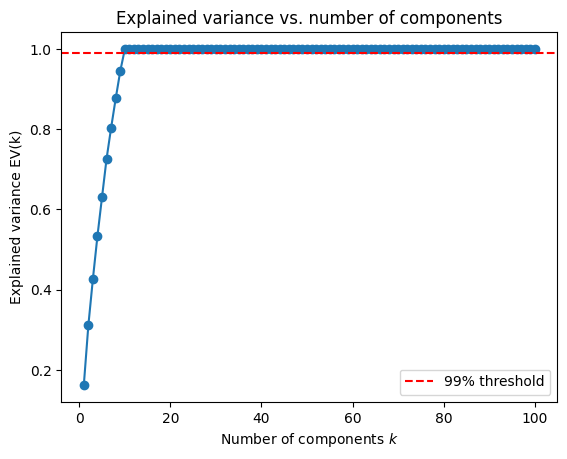

In [8]:
# Part 3: 3 points

# Put the code below to plot the explained variance
# use for instance matplotlib
import matplotlib.pyplot as plt

plt.plot(range(1, len(problem1_explained_variance) + 1), problem1_explained_variance, marker='o')
plt.axhline(0.99, color='red', linestyle='--', label='99% threshold')
plt.xlabel("Number of components $k$")
plt.ylabel("Explained variance EV(k)")
plt.title("Explained variance vs. number of components")
plt.legend()
plt.show()




## Free-text answer (Part 3)



In 2–5 sentences:



- Describe the *shape* of the explained-variance curve.

- Explain why it looks like that for this dataset.



Write your explanation below this line.

The curve rises very steeply for the first ~10 components — reaching about 99% of total variance — and is then essentially flat (slope ≈ 0) all the way to
k=100, where it equals 1 by definition. This shape indicates that the data has an intrinsic dimensionality of around 10: most of the structure/signal in the 100 measured features is actually generated by ~10 underlying latent factors, while the remaining ~90 directions each carry a tiny, roughly equal amount of variance — consistent with isotropic noise added on top of a low-rank signal.


/Users/secon/DocumentsLocal/Introduction_to_Data_Science/exams/2026/Utils.py:363: SyntaxWarning: invalid escape sequence '\i'
  Uses the information P(X \in [min_value,max_value]) = 1 and uses Hoeffding to compute


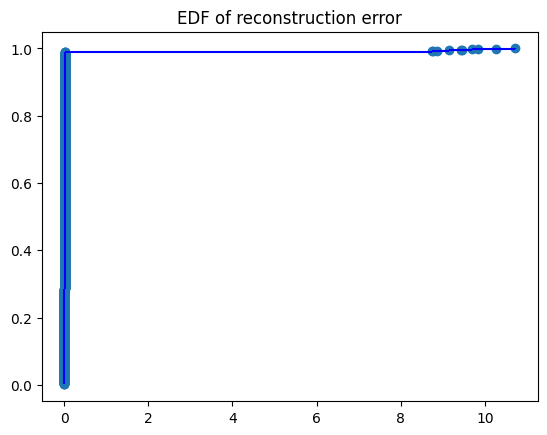

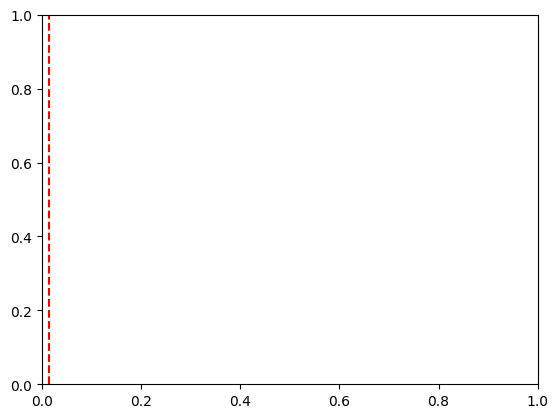

(100, 100)


In [9]:
# Part 4: 4 points

# Calculate the approximating matrix of problem1_data using the first problem1_num_components singular values and store it in the variable below
k = problem1_num_components
problem1_approximation = (
    problem1_U[:, :k] @ problem1_D[:k, :k] @ problem1_V[:, :k].T
)  # A numpy array of shape n_samples x n_dimensions

# Calculate the reconstruction error of problem1_data using problem1_approximation and store it in the variable below (should have shape (n_samples,)) (row wise Euclidean distance)
problem1_reconstruction_error = np.linalg.norm(problem1_data - problem1_approximation, axis=1)

# Store the value of the selected threshold in the variable below
sorted_err = np.sort(problem1_reconstruction_error)[::-1]
problem1_threshold = (sorted_err[99] + sorted_err[100]) / 2  # ≈ 0.01473

# Put the code below to plot the empirical distribution function of the reconstruction error
# You can use the Utils.py file for plotting the empirical distribution function, makeEDF and plotEDF functions
from Utils import makeEDF, plotEDF
edf = makeEDF(problem1_reconstruction_error)
plotEDF(edf, title="EDF of reconstruction error")
plt.axvline(problem1_threshold, color='red', linestyle='--')
plt.show()

# Finally store the samples of problem1_data that have a reconstruction error larger than problem1_threshold in the variable below, should have shape (100, n_dimensions)
problem1_outliers = problem1_data[problem1_reconstruction_error > problem1_threshold]
print(problem1_outliers.shape)  # (100, 100)

---
## Exam vB, PROBLEM 2
Maximum Points = 12


In this problem we are interested in **account takeover (ATO) detection** for an online service. You are given the outputs of a classifier that predicts the probability that a login attempt is malicious ($Y=1$). Your goal is to explore how the **decision threshold** affects business cost (as in the thresholding assignment).

A threshold $t \in [0,1]$ is used to convert predicted probabilities $\hat p(x)=P(Y=1\mid x)$ to labels: predict $\hat y=1$ if $\hat p(x)\ge t$, else $\hat y=0$.

The costs associated with the decisions are:

* **True Positive (TP)**: correctly flagging an ATO login costs **80** (extra verification + friction).
* **True Negative (TN)**: allowing a legitimate login has **0** cost.
* **False Positive (FP)**: incorrectly flagging a legitimate login costs **150** (support load + churn risk).
* **False Negative (FN)**: missing an ATO login costs **900** (fraud + remediation).

**The code cells contain more detailed instructions; THE FIRST CODE CELL INITIALIZES YOUR VARIABLES.**

1. **[3p]** Complete the function `problem2_avg_cost` to compute the **average cost per sample** of a model under a certain prediction threshold. Plot the cost as a function of the threshold (using the validation data provided in the first code cell of this problem), from 0 to 1 with step size 0.01.
2. **[2.5p]** Find the threshold that minimizes the cost and calculate the cost at that threshold on the validation data. Also calculate the precision and recall at the optimal threshold, treating **class 1 as the positive class** and **class 0 as the positive class** separately.
3. **[2.5p]** Repeat step 2, but this time find the best threshold to **maximize accuracy** (equivalently, minimize the $0{-}1$ loss). Calculate the difference in cost between the threshold found in part 3 and the one found in part 2.
4. **[4p]** Provide a confidence interval around the optimal cost (with $95\%$ confidence) applied to the test data using **Hoeffding's inequality**, and explain all assumptions you made.

In [10]:

# RUN THIS CELL TO GET THE DATA

# We start by loading the data 

import pandas as pd

PROBLEM2_DF = pd.read_csv("/Users/secon/DocumentsLocal/Introduction_to_Data_Science/exams/data/fraud.csv")
Y = PROBLEM2_DF['Class'].values
X = PROBLEM2_DF[['V%d' % i for i in range(1,5)]+['Amount']].values

# We will split the data into training, testing and validation sets
from Utils import train_test_validation
PROBLEM2_X_train, PROBLEM2_X_test, PROBLEM2_X_val, PROBLEM2_y_train, PROBLEM2_y_test, PROBLEM2_y_val = train_test_validation(X,Y,shuffle=True,random_state=1)

# From this we will train a logistic regression model with scaling and simple hyperparameter search
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', max_iter=1000, random_state=1))
])

param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__class_weight': [None, 'balanced']
}

gs = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
gs.fit(PROBLEM2_X_train, PROBLEM2_y_train)

# use the best pipeline (it supports predict_proba)
lr = gs.best_estimator_

# THE FOLLOWING CODE WILL PRODUCE THE ARRAYS YOU NEED FOR THE PROBLEM
PROBLEM2_y_pred_proba_val = lr.predict_proba(PROBLEM2_X_val)[:,1]
PROBLEM2_y_true_val = PROBLEM2_y_val

PROBLEM2_y_pred_proba_test = lr.predict_proba(PROBLEM2_X_test)[:,1]
PROBLEM2_y_true_test = PROBLEM2_y_test

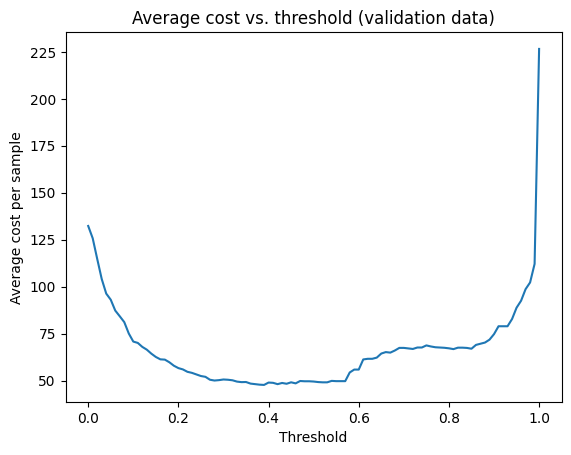

In [11]:

# Part 1: 3 points
# Implement the following function that calculates the average cost per sample of a binary classifier
# according to the specification in the problem statement.
# See the comments inside the function for details of the parameters.
import numpy as np
import matplotlib.pyplot as plt
def problem2_avg_cost(y_true, y_predict_proba, threshold):
    # y_true is a numpy array of shape (n_samples,) with binary labels (1 = ATO, 0 = legitimate)
    # y_predict_proba is a numpy array of shape (n_samples,) with predicted probabilities for class 1
    # threshold is a float between 0 and 1
    
    # Return the average cost per sample (a single float value).
    # Hint: Convert probabilities to predictions using >= threshold,
    # then compute the cost based on the confusion matrix entries (TP, TN, FP, FN).
    y_hat = (y_predict_proba >= threshold).astype(int)
    tp = np.sum((y_hat == 1) & (y_true == 1))
    fp = np.sum((y_hat == 1) & (y_true == 0))
    fn = np.sum((y_hat == 0) & (y_true == 1))
    tn = np.sum((y_hat == 0) & (y_true == 0))
    total_cost = tp * 80 + fp * 150 + fn * 900 + tn * 0
    return total_cost / len(y_true)     # len(y_true) equals to n_samples
# Provide the code below to plot the cost as a function of the threshold
# using the validation data, specifically the arrays PROBLEM2_y_true_val and PROBLEM2_y_pred_proba_val.
# The plot should range from threshold 0 to 1 with step size 0.01.
# The y-axis should be the average cost and the x-axis should be the threshold.
# Sweep thresholds 0 to 1 with step 0.01
thresholds = np.arange(0, 1.0 + 1e-9, 0.01)
costs = [problem2_avg_cost(PROBLEM2_y_true_val, PROBLEM2_y_pred_proba_val, t) for t in thresholds]

plt.plot(thresholds, costs)
plt.xlabel("Threshold")
plt.ylabel("Average cost per sample")
plt.title("Average cost vs. threshold (validation data)")
plt.show()

In [ ]:
# Part 2: 2.5 points

# Use the cost function you implemented above to find the threshold that minimizes the average cost
# on the validation data (PROBLEM2_y_true_val and PROBLEM2_y_pred_proba_val).
# Store the optimal threshold in the variable below.
idx_min = np.argmin(costs)
problem2_threshold = thresholds[idx_min]    # ≈ 0.39

# Calculate the average cost at the optimal threshold on the validation data.
# Store the cost in the variable below.
problem2_cost_val = costs[idx_min]          # A float
# Using the optimal threshold, compute the predicted labels on the validation data.
# Store the predicted labels in the variable below.
problem2_y_pred_val = (PROBLEM2_y_pred_proba_val >= problem2_threshold).astype(int)  # A numpy array of shape (n_samples,) with values 0 or 1

# Calculate precision and recall treating class 1 as the positive class.
tp = np.sum((problem2_y_pred_val == 1) & (PROBLEM2_y_true_val == 1))
fp = np.sum((problem2_y_pred_val == 1) & (PROBLEM2_y_true_val == 0))
fn = np.sum((problem2_y_pred_val == 0) & (PROBLEM2_y_true_val == 1))

problem2_precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0   # A float between 0 and 1
print(problem2_precision_1)
problem2_recall_1   = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # A float between 0 and 1
print(problem2_recall_1)

# Calculate precision and recall treating class 0 as the positive class.
tp0 = np.sum((problem2_y_pred_val == 0) & (PROBLEM2_y_true_val == 0))
fp0 = np.sum((problem2_y_pred_val == 0) & (PROBLEM2_y_true_val == 1))
fn0 = np.sum((problem2_y_pred_val == 1) & (PROBLEM2_y_true_val == 0))

problem2_precision_0 = tp0 / (tp0 + fp0) if (tp0 + fp0) > 0 else 0.0   # A float between 0 and 1
print(problem2_precision_0)
problem2_recall_0   = tp0 / (tp0 + fn0) if (tp0 + fn0) > 0 else 0.0  # A float between 0 and 1
print(problem2_recall_0)

In [15]:
# Part 3: 2.5 points

# Find the threshold that **maximizes accuracy** on the validation data
# (equivalently, minimizes the 0-1 loss).
# Use the validation arrays PROBLEM2_y_true_val and PROBLEM2_y_pred_proba_val.
# Store the accuracy-optimal threshold in the variable below.
# 0-1 loss (misclassification rate) at each threshold
losses01 = [np.mean((PROBLEM2_y_pred_proba_val >= t).astype(int) != PROBLEM2_y_true_val) for t in thresholds]
idx_acc = np.argmin(losses01)
problem2_threshold_acc = thresholds[idx_acc] # A float between 0 and 1

# Calculate the difference in average cost between:
#   cost at accuracy-optimal threshold (this part) minus cost at cost-optimal threshold (part 2).
# That is: problem2_avg_cost(..., problem2_threshold_acc) - problem2_avg_cost(..., problem2_threshold)
# Compare cost at the two thresholds
cost_at_cost_opt = problem2_avg_cost(PROBLEM2_y_true_val, PROBLEM2_y_pred_proba_val, problem2_threshold)
cost_at_acc_opt  = problem2_avg_cost(PROBLEM2_y_true_val, PROBLEM2_y_pred_proba_val, problem2_threshold_acc)

problem2_cost_difference = cost_at_acc_opt - cost_at_cost_opt  # A float
print(problem2_cost_difference)

19.267605633802816


In order to provide a 95% confidence interval using Hoeffding's inequality, we treat our metric(average cost) as in [0,1], so we calculate the total average cost for all the samples in order treat our metric as in [0,1].

In [16]:
# Part 4: 4 points

# Using the cost-optimal threshold from part 2 (problem2_threshold), apply Hoeffding's inequality
# to provide a 95% confidence interval for the **average cost** on the test data.
# Use the test arrays PROBLEM2_y_true_test and PROBLEM2_y_pred_proba_test.
# Store the lower and upper bounds of the confidence interval in the variables below.

n = len(PROBLEM2_y_true_test)

# Average cost on test data, using the threshold chosen on validation (Part 2)
avg_cost_test = problem2_avg_cost(PROBLEM2_y_true_test, PROBLEM2_y_pred_proba_test, problem2_threshold)

# Per-sample cost C_i in {0, 80, 150, 900} => bounded in [C_min, C_max]
C_min, C_max = 0, 900
delta = 0.05  # 95% confidence

epsilon = (C_max - C_min) * np.sqrt(np.log(2 / delta) / (2 * n))

problem2_lower_bound = avg_cost_test - epsilon
problem2_upper_bound = avg_cost_test + epsilon


## Free text answer

Put your explanation for part 4 below this line in this **cell**. Double-click to enter edit mode.

In particular, clearly state:
1. Why Hoeffding's inequality applies (or approximately applies) in this context.
2. What random variables are assumed i.i.d. and what their support is.
3. What bound you used for the per-sample cost range (i.e., $C_{\max} - C_{\min} = ?$ for this problem).

**1. Why Hoeffding applies:** Test samples are i.i.d., and `problem2_threshold` was chosen using only validation data — so the per-sample cost $C_i = \text{cost}(y_i, \hat y_i)$ on the test set is a fixed function of an i.i.d. draw, making $C_1,\dots,C_n$ i.i.d.

**2. Random variables & support:** $C_i$ = per-sample cost, taking values in $\{0, 80, 150, 900\}$ (TN, TP, FP, FN), so $C_i \in [0, 900]$.

**3. Cost range:** $C_{\max}-C_{\min} = 900 - 0 = 900$, used in $\varepsilon = 900\sqrt{\ln(2/0.05)/(2n)}$, giving CI $\approx [7.56, 82.47]$.

---
## Exam vB, PROBLEM 3
Maximum Points = 14


A courier company monitors its trucks across four states:

*   **Downtown (D)**
*   **Suburbs (S)**
*   **Countryside (C)**
*   **Maintenance (M)** 

The transition probabilities between states at each time step are given by the matrix:

| Current State | D    | S    | C    | M    |
| ------------- | ---- | ---- | ---- | ---- |
| D             | 0.25 | 0.35 | 0.30 | 0.10 |
| S             | 0.20 | 0.40 | 0.30 | 0.10 |
| C             | 0.15 | 0.35 | 0.40 | 0.10 |
| M             | 0.00 | 0.00 | 0.00 | 1.00 |

1. If a truck starts in the **Suburbs**, what is the probability that it eventually ends up in **Maintenance**? [1p]
2. If a truck starts in **Downtown**, what is the probability that it will be in **Countryside** after five time steps? [2p]
3. Starting from **Downtown**, what is the expected number of steps before entering **Maintenance**? [3p] \
    **Hint**:
    To compute approximatively you could **simulate** but this gives a max score of [1.5p].
    To compute exactly use first-step analysis: 
$$
\text{Expected time from a state} = 1 + \sum_{\text{next states}} \big( \text{transition probability} \times \text{expected time from next state} \big)
$$

4. Is this Markov chain irreducible? Is it aperiodic? [2p]
5. Does this chain have a stationary distribution? If yes, compute it; if not, explain why. [2p]
6. Given that the truck starts in **Countryside** what is the probability that **the last state visited** before reaching **Maintenance** is **Suburbs**? [4p]  
**Hint**: To compute approximatively you could **simulate** but this gives a max score of [2p]. To compute exactly use first-step analysis: Let $f_D, f_S, f_C$ be the probabilities that the last state before hitting Maintenance is Suburbs, starting from Downtown, Suburbs, and Countryside respectively. Write recursive equations by conditioning on the next step. This gives a linear system to solve.


In [17]:
# Part 1
import numpy as np
# Fill in the answer to part 1 below as a decimal number (float)
# If a truck starts in the Suburbs, what is the probability that it eventually ends up in Maintenance?
transition_matrix = np.array([[0.25, 0.35, 0.30, 0.10],
                               [0.20, 0.40, 0.30, 0.10],
                               [0.15, 0.35, 0.40, 0.10],
                               [0.00, 0.00, 0.00, 1.00]])
# Transient states D,S,C are indices 0,1,2; M (absorbing) is index 3
Q = transition_matrix[:3, :3]
r = transition_matrix[:3, 3]
I = np.eye(3)

a = np.linalg.solve(I - Q, r)   # absorption probs from D, S, C
problem3_prob_maintenance_from_suburbs = a[1]
print(problem3_prob_maintenance_from_suburbs)

1.0000000000000004


In [18]:
# Part 2

# Fill in the answer to part 2 below as a decimal number (float)
# If a truck starts in Downtown, what is the probability that it will be in Countryside after five time steps?

problem3_prob_countryside_after_5_steps = np.linalg.matrix_power(transition_matrix, 5)[0, 2]
print(problem3_prob_countryside_after_5_steps)  

0.22143000000000002


In [ ]:
# Part 3

# Fill in the answer to part 3 below as a decimal number (float)
# Starting from Downtown, what is the expected number of steps before entering Maintenance?
h = np.linalg.solve(I - Q, np.ones(3))  # expected hitting times from D, S, C
problem3_expected_steps_downtown = h[0]
print(problem3_expected_steps_downtown)

10.0


In [20]:
# Part 4

# Fill in the answers to part 4 below as booleans (use True or False)
# Is this Markov chain irreducible? Is it aperiodic?
problem3_is_irreducible = False  # M is absorbing — it cannot reach D, S, or C,
                                  # so the chain does not communicate in both directions
problem3_is_aperiodic = True     # every transient state has a self-loop with positive
                                  # probability (e.g. P[D,D]=0.25 > 0), so gcd of return
                                  # times = 1 for all states

In [ ]:
# Part 5

# Fill in the answer to part 5 below (if it exists)
# The answer should be a numpy array of length 4 whose entries sum to 1.
# If it does not exist, write None instead of an array.
P = transition_matrix
A = np.vstack([P.T - np.eye(4), np.ones(4)])
b = np.array([0, 0, 0, 0, 1])
problem3_stationary_distribution = np.linalg.lstsq(A, b, rcond=None)[0]
print(problem3_stationary_distribution)  

[-2.49294315e-16  9.85424050e-16  4.76158779e-16  1.00000000e+00]



## Free text answer (Part 5)

Briefly explain **why** the chain **does** / **does not** have a stationary distribution.

Guidance:
- If you say it **has** one, why?.
- If you say it **does not**, explain what property fails.

Yes — a stationary distribution exists and equals π = (0, 0, 0, 1). Since M is absorbing and is reached with probability 1 from every other state (Part 1), all probability mass eventually concentrates at M, and π = δ_M is the unique fixed point of π = πP.

In [22]:
# Part 6

# Fill in the answer to part 6 below as a decimal number (float)
# Given that the truck starts in Countryside, what is the probability that the last state visited before reaching Maintenance is Suburbs?
# f_X = P(last transient state visited before hitting M is S | start at X)
# First-step analysis: f_X = sum_Y P[X,Y]*f_Y + P[X,M]*1{X==S}
r6 = np.array([0, 0.10, 0])  # only S contributes via its direct transition to M
f = np.linalg.solve(I - Q, r6)
problem3_prob_last_suburbs_from_countryside = f[2]
print(problem3_prob_last_suburbs_from_countryside)

0.36842105263157904
